# Chopper cascade acceptance for unwrapping and wavelength frame multiplication

In this notebook, we show how to use a new fast workflow from `essreduce`'s `unwrap` module to compute neutron wavelengths based on a chopper acceptance diagram for a pulse of neutrons travelling through two WFM beamlines:
the DREAM and ODIN instruments.

## The DREAM chopper cascade

The case of DREAM is interesting because the pulse-shaping choppers can be used in a number of different modes,
and the number of cutouts the choppers have typically does not equal the number of frames observed at the detectors.

In [1]:
import plopp as pp
import scipp as sc
import scippnexus as snx
from scippneutron.chopper import DiskChopper
from ess.reduce.nexus.types import RawDetector, SampleRun, NeXusDetectorName, Position
from ess.reduce.unwrap import *

### Creating the beamline choppers

We begin by defining the chopper settings for our beamline.
In principle, the chopper setting could simply be read from a NeXus file.

The DREAM instrument has

- 2 pulse-shaping choppers (PSC)
- 1 overlap chopper (OC)
- 1 band-control chopper (BCC)
- 1 T0 chopper

In [2]:
psc1 = DiskChopper(
    frequency=sc.scalar(14.0, unit="Hz"),
    beam_position=sc.scalar(0.0, unit="deg"),
    phase=sc.scalar(286 - 180, unit="deg"),
    axle_position=sc.vector(value=[0, 0, -70.405], unit="m"),
    slit_begin=sc.array(
        dims=["cutout"],
        values=[-1.23, 70.49, 84.765, 113.565, 170.29, 271.635, 286.035, 301.17],
        unit="deg",
    ),
    slit_end=sc.array(
        dims=["cutout"],
        values=[1.23, 73.51, 88.035, 116.835, 175.31, 275.565, 289.965, 303.63],
        unit="deg",
    ),
    slit_height=sc.scalar(10.0, unit="cm"),
    radius=sc.scalar(30.0, unit="cm"),
)

psc2 = DiskChopper(
    frequency=sc.scalar(-14.0, unit="Hz"),
    beam_position=sc.scalar(0.0, unit="deg"),
    phase=sc.scalar(-236, unit="deg"),
    axle_position=sc.vector(value=[0, 0, -70.395], unit="m"),
    slit_begin=sc.array(
        dims=["cutout"],
        values=[-1.23, 27.0, 55.8, 142.385, 156.765, 214.115, 257.23, 315.49],
        unit="deg",
    ),
    slit_end=sc.array(
        dims=["cutout"],
        values=[1.23, 30.6, 59.4, 145.615, 160.035, 217.885, 261.17, 318.11],
        unit="deg",
    ),
    slit_height=sc.scalar(10.0, unit="cm"),
    radius=sc.scalar(30.0, unit="cm"),
)

oc = DiskChopper(
    frequency=sc.scalar(14.0, unit="Hz"),
    beam_position=sc.scalar(0.0, unit="deg"),
    phase=sc.scalar(297 - 180 - 90, unit="deg"),
    axle_position=sc.vector(value=[0, 0, -70.376], unit="m"),
    slit_begin=sc.array(dims=["cutout"], values=[-27.6 * 0.5], unit="deg"),
    slit_end=sc.array(dims=["cutout"], values=[27.6 * 0.5], unit="deg"),
    slit_height=sc.scalar(10.0, unit="cm"),
    radius=sc.scalar(30.0, unit="cm"),
)

bcc = DiskChopper(
    frequency=sc.scalar(112.0, unit="Hz"),
    beam_position=sc.scalar(0.0, unit="deg"),
    phase=sc.scalar(240 - 180, unit="deg"),
    axle_position=sc.vector(value=[0, 0, -66.77], unit="m"),
    slit_begin=sc.array(dims=["cutout"], values=[-36.875, 143.125], unit="deg"),
    slit_end=sc.array(dims=["cutout"], values=[36.875, 216.875], unit="deg"),
    slit_height=sc.scalar(10.0, unit="cm"),
    radius=sc.scalar(30.0, unit="cm"),
)

t0 = DiskChopper(
    frequency=sc.scalar(28.0, unit="Hz"),
    beam_position=sc.scalar(0.0, unit="deg"),
    phase=sc.scalar(280 - 180, unit="deg"),
    axle_position=sc.vector(value=[0, 0, -63.5], unit="m"),
    slit_begin=sc.array(dims=["cutout"], values=[-314.9 * 0.5], unit="deg"),
    slit_end=sc.array(dims=["cutout"], values=[314.9 * 0.5], unit="deg"),
    slit_height=sc.scalar(10.0, unit="cm"),
    radius=sc.scalar(30.0, unit="cm"),
)

disk_choppers = {"psc1": psc1, "psc2": psc2, "oc": oc, "bcc": bcc, "t0": t0}

It is possible to visualize the properties of the choppers by inspecting their `repr`:

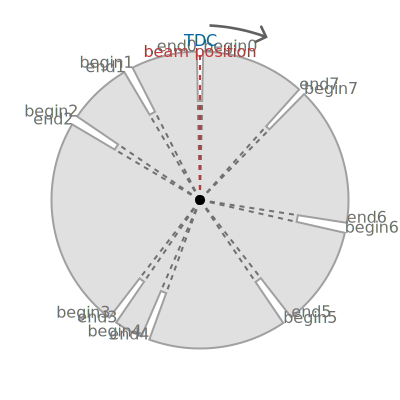

In [3]:
psc2

Define the source position which is required to compute the distance that neutrons travelled.

In [4]:
source_position = sc.vector([0, 0, -76.55], unit="m")

### Adding a detector

In [5]:
Ltotal = sc.scalar(60.0, unit="m")

### Creating some neutron events

We create a semi-realistic set of neutron events based on the ESS pulse.

In [6]:
from ess.reduce.unwrap.fakes import FakeBeamline

ess_beamline = FakeBeamline(
    choppers=disk_choppers,
    source_position=source_position,
    monitors={"detector": Ltotal},
    run_length=sc.scalar(1 / 14, unit="s") * 4,
    events_per_pulse=200_000,
)

The initial birth times and wavelengths of the generated neutrons can be visualized (for a single pulse):

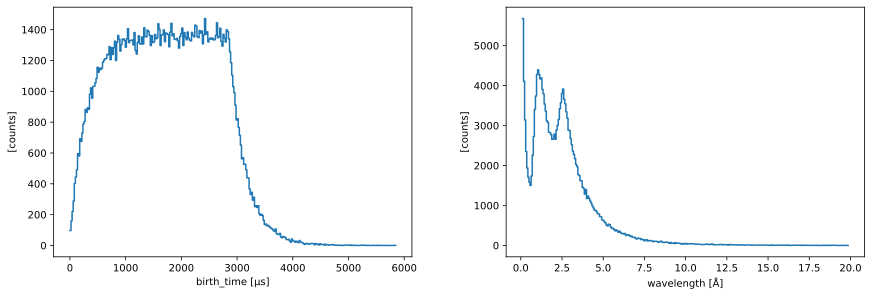

In [7]:
one_pulse = ess_beamline.source.data["pulse", 0]
one_pulse.hist(birth_time=300).plot() + one_pulse.hist(wavelength=300).plot()

Plot(ax=<Axes: xlabel='Time [μs]', ylabel='Distance [m]'>, fig=<Figure size 1200x480 with 2 Axes>)

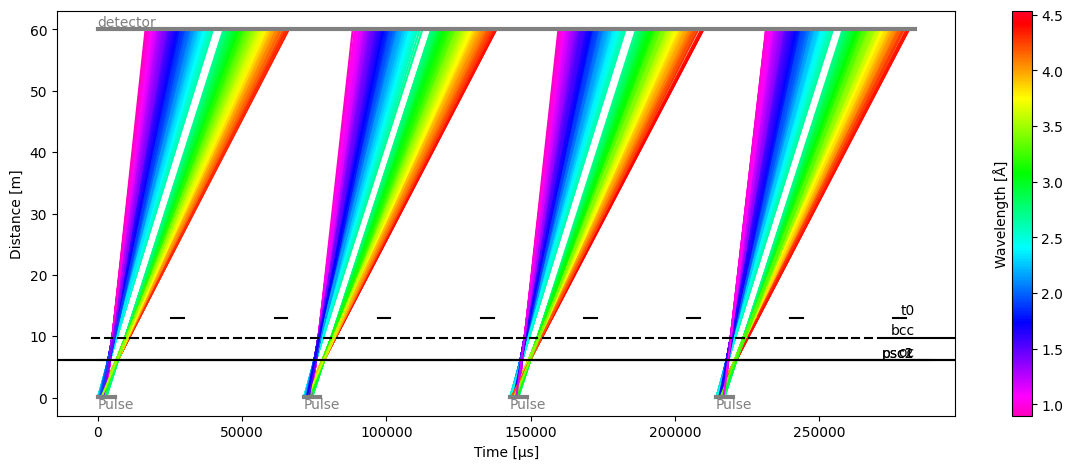

In [8]:
ess_beamline.model_result.plot()

From this fake beamline, we extract the raw neutron signal at our detector:

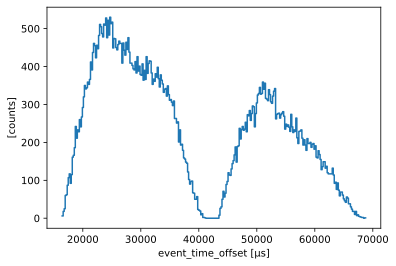

In [9]:
raw_data = ess_beamline.get_monitor("detector")[0]

# Visualize
raw_data.hist(event_time_offset=300).squeeze().plot()

The total number of neutrons in our sample data that make it through to the detector is:

In [10]:
raw_data.sum().value

np.float64(69257.0)

### Computing neutron wavelengths

Next, we use a workflow that computes the neutron wavelength from the neutron time-of-arrival.

#### Setting up the workflow

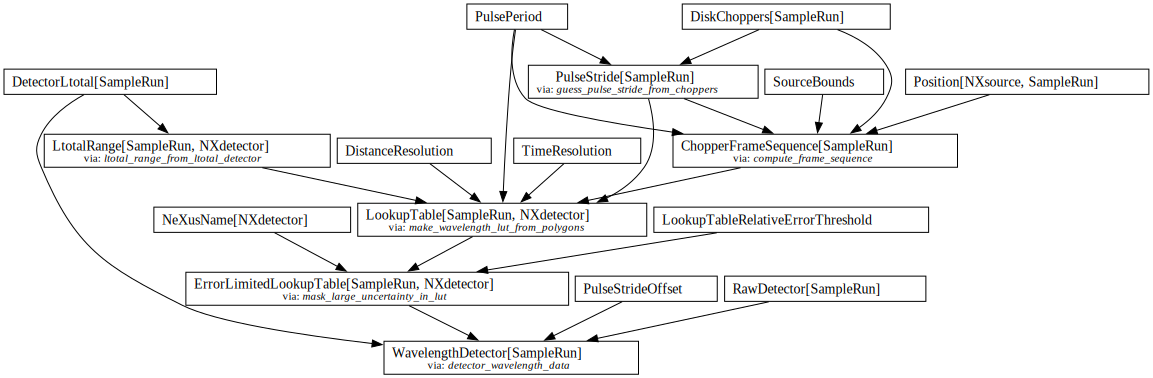

In [11]:
wf = GenericUnwrapWorkflow(
    run_types=[SampleRun], monitor_types=[], wavelength_from="analytical"
)

wf[RawDetector[SampleRun]] = raw_data
wf[DetectorLtotal[SampleRun]] = Ltotal
wf[Position[snx.NXsource, SampleRun]] = source_position
wf[NeXusDetectorName] = 'dream_detector'
wf[DiskChoppers[SampleRun]] = disk_choppers
wf[LookupTableRelativeErrorThreshold] = {'dream_detector': float("inf")}

wf.visualize(WavelengthDetector[SampleRun])

#### Inspecting the lookup table

The workflow first uses the [`scippneutron.tof.chopper_cascade`](https://scipp.github.io/scippneutron/user-guide/chopper/chopper-cascade.html)
module to propagate a pulse of neutrons (represented by a polygon in time and wavelength space)
through a chopper cascade defined by the chopper parameters above.

This can be used to create a figure displaying the neutron wavelengths,
as a function of arrival time at the detector.

This is the basis for creating our lookup table, on which bilinear interpolation is used further down to compute a wavelength for every neutron event.

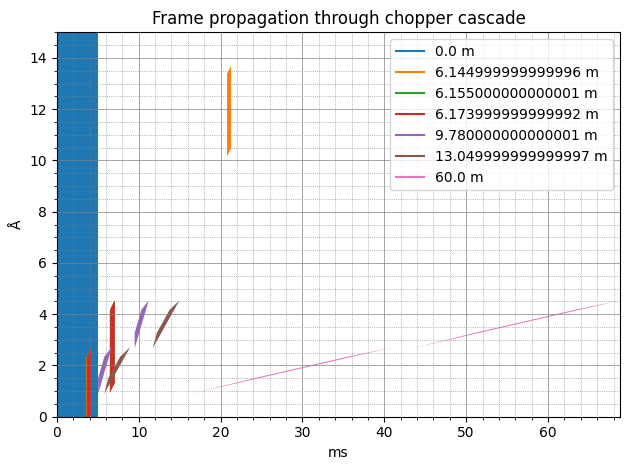

In [12]:
dist = sc.scalar(60.0, unit='m')

frames = wf.compute(ChopperFrameSequence[SampleRun])
at_detector = frames.propagate_to(dist)
fig, ax = at_detector.draw()

The source pulse is defined as spanning 0-5 ms in time, and 0-15 Å in wavelength,
and is represented by the blue rectangle on the left hand side of the diagram.

As the pulse propagates through the system,
it stretches (slow neutrons take longer to reach the same distance) and gets chopped by the chopper openings,
creating polygons from the rectangular pulse.

Finally, at the detector distance of 60 m, we are left with two (pink) very thin polygons,
representing the two packets of neutrons that are allowed through the instrument.

The idea is to approximate these thin polygons as a single line,
effectively giving us a function relating neutron wavelength as a function of arrival time.
This is precisely how the loop table is built,
and if we overlay the wavelength values given by the table at a distance of 60 m,
we see that the black lines pass right in the middle of the polygons.

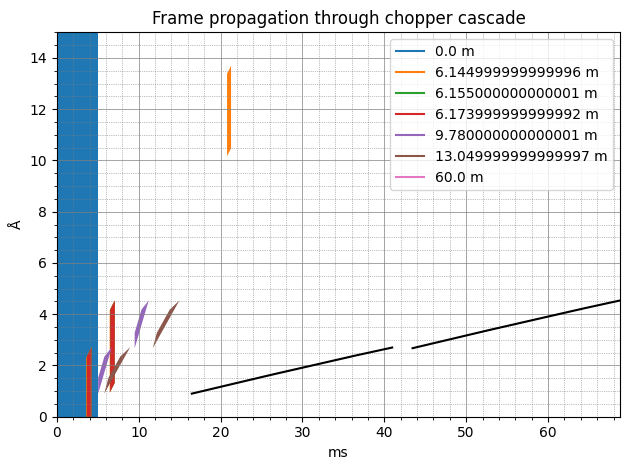

In [13]:
table = wf.compute(LookupTable[SampleRun, snx.NXdetector])

# Overlay LUT prediction on the polygons figure
da = table.array["distance", 2]
ax.plot(
    da.coords['event_time_offset'].values / 1000,
    da.values,
    color="k",
    ls="-",
    marker=None,
)
fig

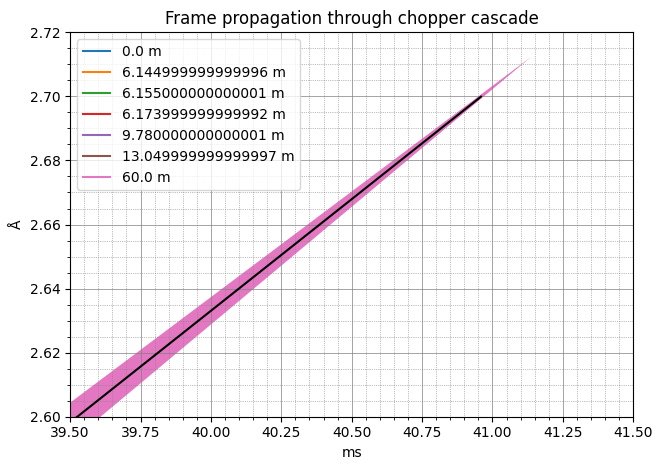

In [14]:
ax.set(xlim=[39.5, 41.5], ylim=[2.6, 2.72])
fig

The full table covers a range of distances, and looks like

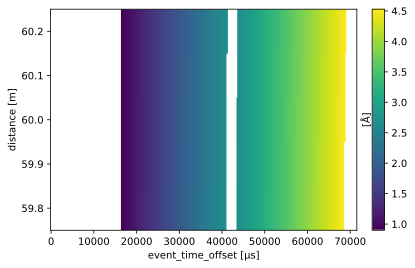

In [15]:
table.plot()

#### Computing a wavelength coordinate

We will now use our workflow once again to obtain our event data with a wavelength coordinate (a step further down in the pipeline):

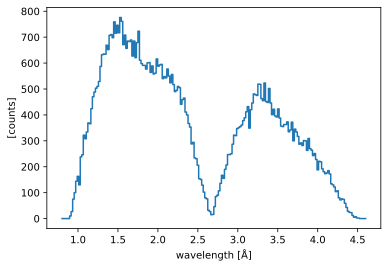

In [16]:
# Compute wavelength of neutron events
wavs = wf.compute(WavelengthDetector[SampleRun])
edges = sc.linspace("wavelength", 0.8, 4.6, 201, unit="angstrom")

histogrammed = wavs.hist(wavelength=edges).squeeze()
histogrammed.plot()

#### Comparing to the ground truth

As a consistency check, because we actually know the wavelengths of the neutrons we created,
we can compare the true neutron wavelengths to those we computed above.

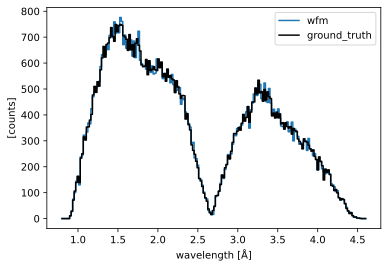

In [17]:
ground_truth = ess_beamline.model_result["detector"].data.flatten(to="event")
ground_truth = ground_truth[~ground_truth.masks["blocked_by_others"]]

pp.plot(
    {
        "wfm": histogrammed,
        "ground_truth": ground_truth.hist(wavelength=edges),
    },
    color={"ground_truth": "k"},
)

### Multiple detector pixels

It is also possible to compute the neutron wavelength for multiple detector pixels at once,
where every pixel has different frame bounds
(because every pixel is at a different distance from the source).

In our setup, we simply propagate the same neutrons to multiple detector pixels,
as if they were not absorbed by the first pixel they meet.

In [18]:
Ltotal = sc.array(dims=["detector_number"], values=[59.0, 60.0], unit="m")
monitors = {f"detector{i}": ltot for i, ltot in enumerate(Ltotal)}

ess_beamline = FakeBeamline(
    choppers=disk_choppers,
    source_position=source_position,
    monitors=monitors,
    run_length=sc.scalar(1 / 14, unit="s") * 4,
    events_per_pulse=200_000,
)

Our raw data has now a `detector_number` dimension of length 2.

We can plot the neutron `event_time_offset` for the two detector pixels and see that the offsets are shifted to the left for the pixel that is closest to the source.

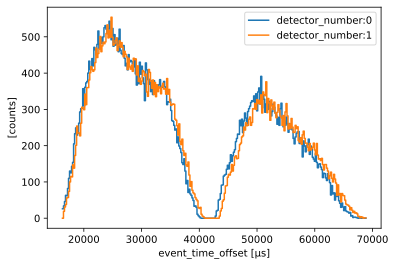

In [19]:
raw_data = sc.concat(
    [ess_beamline.get_monitor(key)[0].squeeze() for key in monitors.keys()],
    dim="detector_number",
)

# Visualize
pp.plot(sc.collapse(raw_data.hist(event_time_offset=300), keep="event_time_offset"))

Computing wavelength is done in the same way as above.
We need to remember to update our workflow:

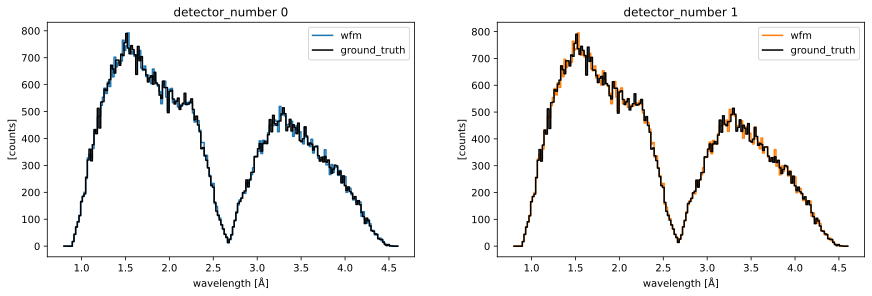

In [20]:
# Update workflow
wf[RawDetector[SampleRun]] = raw_data
wf[DetectorLtotal[SampleRun]] = Ltotal

# Compute tofs and wavelengths
wav_wfm = wf.compute(WavelengthDetector[SampleRun])

# Compare in plot
ground_truth = []
for det in ess_beamline.monitors:
    data = ess_beamline.model_result[det.name].data.flatten(to="event")
    ground_truth.append(data[~data.masks["blocked_by_others"]])

figs = [
    pp.plot(
        {
            "wfm": wav_wfm["detector_number", i].bins.concat().hist(wavelength=edges),
            "ground_truth": ground_truth[i].hist(wavelength=edges),
        },
        title=f"detector_number {i}",
        color={"ground_truth": "k", "wfm": f"C{i}"},
    )
    for i in range(len(Ltotal))
]

figs[0] + figs[1]

### Handling time overlap between subframes

In some (relatively rare) cases, where a chopper cascade is slightly ill-defined,
it is sometimes possible for some subframes to overlap in time with other subframes.

This is basically when neutrons passed through different pulse-shaping chopper openings,
but arrive at the same time at the detector.

In this case, it is actually not possible to accurately determine the wavelength of the neutrons.
We handle this by masking the overlapping regions and throwing away any neutrons that lie within it.

To simulate this, we modify slightly the phase and the cutouts of the band-control chopper:

Plot(ax=<Axes: xlabel='Time [μs]', ylabel='Distance [m]'>, fig=<Figure size 1200x480 with 2 Axes>)

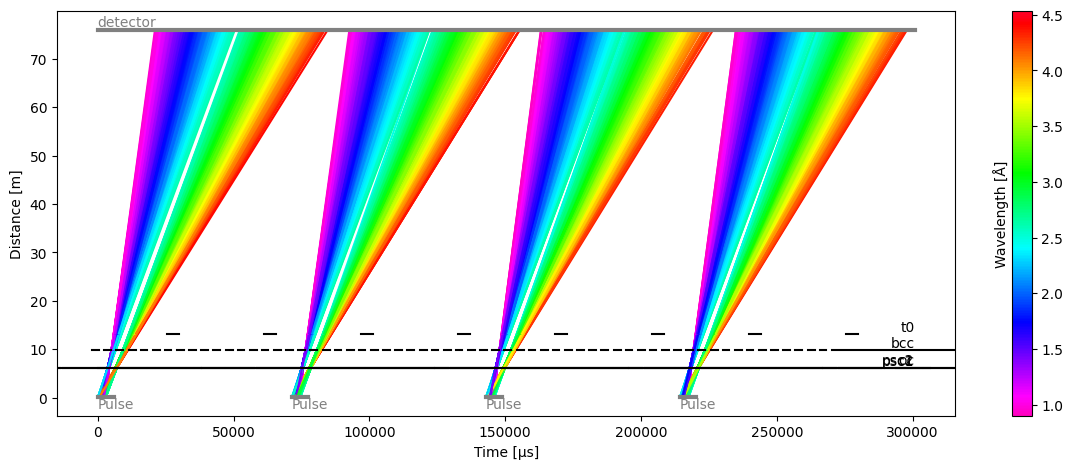

In [21]:
disk_choppers["bcc"] = DiskChopper(
    frequency=sc.scalar(112.0, unit="Hz"),
    beam_position=sc.scalar(0.0, unit="deg"),
    phase=sc.scalar(240 - 180, unit="deg"),
    axle_position=sc.vector(value=[0, 0, -66.77], unit="m"),
    slit_begin=sc.array(dims=["cutout"], values=[-36.875, 143.125], unit="deg"),
    slit_end=sc.array(dims=["cutout"], values=[46.875, 216.875], unit="deg"),
    slit_height=sc.scalar(10.0, unit="cm"),
    radius=sc.scalar(30.0, unit="cm"),
)

# Go back to a single detector pixel
Ltotal = sc.scalar(76.0, unit="m")

ess_beamline = FakeBeamline(
    choppers=disk_choppers,
    source_position=source_position,
    monitors={"detector": Ltotal},
    run_length=sc.scalar(1 / 14, unit="s") * 4,
    events_per_pulse=200_000,
)

ess_beamline.model_result.plot()

We can now see that there is no longer a gap between the two frames at the center of each pulse (green region).

Another way of looking at this is looking at the wavelength vs time-of-arrival plot,
which also shows overlap in time at the junction between the two frames:

[(36.0, 44.0), (2.0, 3.0)]

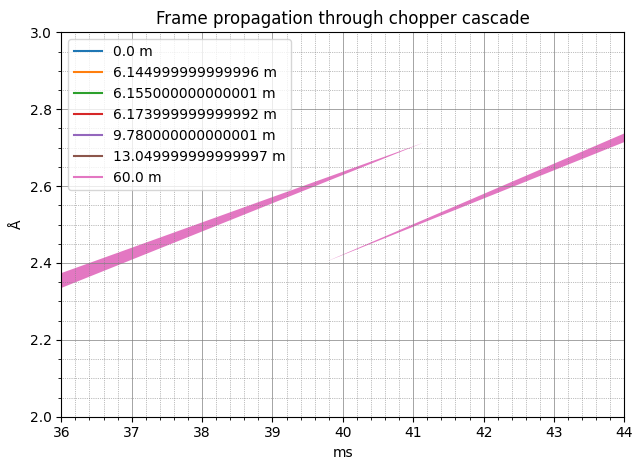

In [22]:
# Update workflow
wf[DiskChoppers[SampleRun]] = disk_choppers
wf[DetectorLtotal[SampleRun]] = Ltotal

frames = wf.compute(ChopperFrameSequence[SampleRun])
at_detector = frames.propagate_to(dist)
fig, ax = at_detector.draw()
ax.set(xlim=(36, 44), ylim=(2, 3))

The data in the lookup table contains both the mean wavelength for each distance and time-of-arrival bin,
but also the variance inside each bin.

In the regions where there is no time overlap,
the variance is small (the regions are close to a thin line).
However, in the central region where overlap occurs,
we are computing a mean between two regions which have similar 'brightness'.

This leads to a large variance, and this is visible when plotting the relative standard deviations on a 2D figure
(we zoom in on the distances corresponding to the detector banks around 75m from the source).

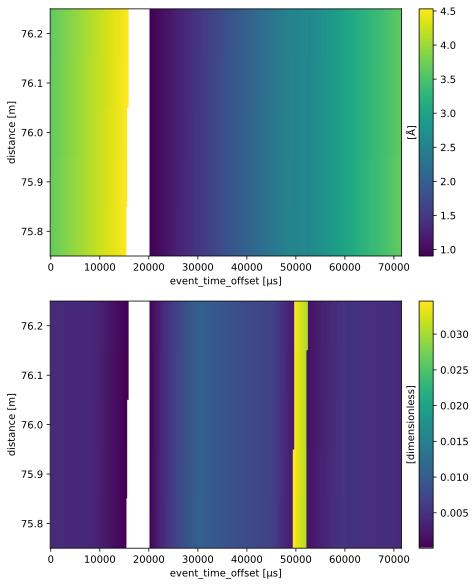

In [23]:
table = wf.compute(LookupTable[SampleRun, snx.NXdetector])
table.plot() / (sc.stddevs(table.array) / sc.values(table.array)).plot()

The workflow has a parameter which is used to mask out regions where the standard deviation is above a certain threshold.

It is difficult to automatically detector this threshold,
as it can vary a lot depending on how much signal is received by the detectors,
and how far the detectors are from the source.
It is thus more robust to simply have a user tunable parameter on the workflow.

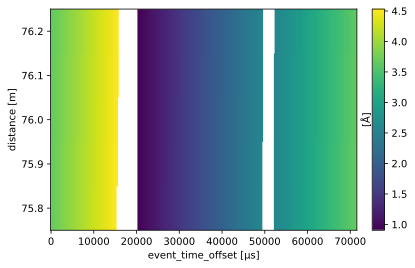

In [24]:
wf[LookupTableRelativeErrorThreshold] = {'dream_detector': 0.02}

masked_table = wf.compute(ErrorLimitedLookupTable[SampleRun, snx.NXdetector])
masked_table.plot()

We can now see that the central region is masked out.

The neutrons in that region will be discarded in the wavelength calculation
(in practice, they are given a NaN value as a wavelength).

This is visible when comparing to the true neutron wavelengths,
where we see that some counts were lost between the two frames.

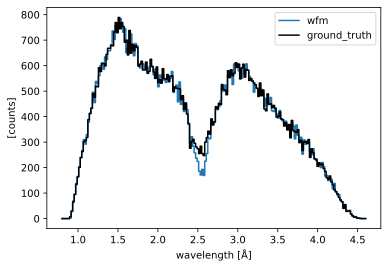

In [25]:
wf[RawDetector[SampleRun]] = ess_beamline.get_monitor("detector")[0]

# Compute wavelength
wav_wfm = wf.compute(WavelengthDetector[SampleRun])

# Compare to the true wavelengths
ground_truth = ess_beamline.model_result["detector"].data.flatten(to="event")
ground_truth = ground_truth[~ground_truth.masks["blocked_by_others"]]

pp.plot(
    {
        "wfm": wav_wfm.hist(wavelength=edges).squeeze(),
        "ground_truth": ground_truth.hist(wavelength=edges),
    },
    color={"ground_truth": "k"},
)

## The ODIN instrument

The second example is the ODIN instrument;
it is a more classical case in the sense that the WFM choppers have 6 openings and produce 6 neutron frames at the detector.

However, it uses a technique called 'pulse-skipping' where a chopper rotating at half the source frequency blocks (or 'skips') every other pulse.
This allows the range of wavelengths recorded at the detector to be much wider,
because overlap between consecutive pulses has been reduced by a factor of 2.

### Setting up the beamline and data

We begin by defining the chopper parameters and creating fake events, as we did previously for DREAM.

Plot(ax=<Axes: xlabel='Time [μs]', ylabel='Distance [m]'>, fig=<Figure size 1200x480 with 2 Axes>)

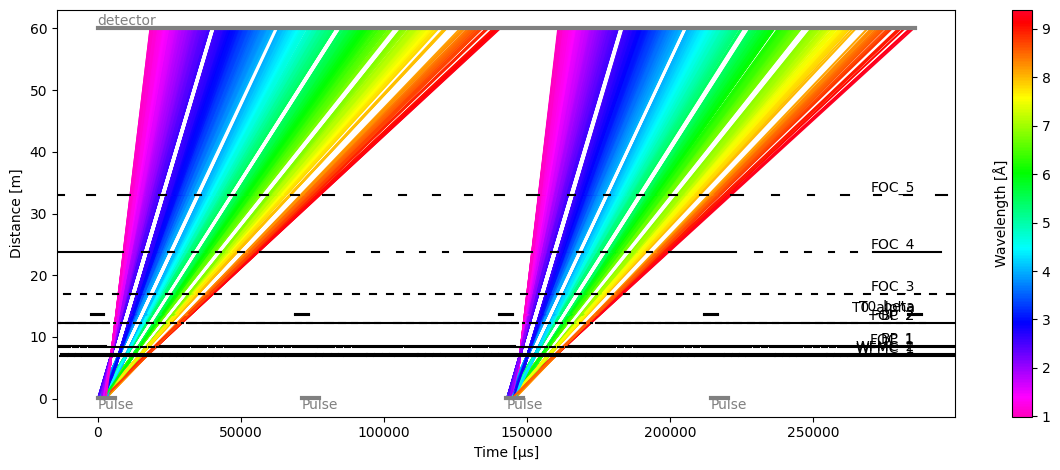

In [26]:
parameters = {
    "WFMC_1": {
        "frequency": 56.0,
        "phase": 93.244,
        "distance": 6.85,
        "open": [-1.9419, 49.5756, 98.9315, 146.2165, 191.5176, 234.9179],
        "close": [1.9419, 55.7157, 107.2332, 156.5891, 203.8741, 249.1752],
    },
    "WFMC_2": {
        "frequency": 56.0,
        "phase": 97.128,
        "distance": 7.15,
        "open": [-1.9419, 51.8318, 103.3493, 152.7052, 199.9903, 245.2914],
        "close": [1.9419, 57.9719, 111.6510, 163.0778, 212.3468, 259.5486],
    },
    "FOC_1": {
        "frequency": 42.0,
        "phase": 81.303297,
        "distance": 8.4,
        "open": [-5.1362, 42.5536, 88.2425, 132.0144, 173.9497, 216.7867],
        "close": [5.1362, 54.2095, 101.2237, 146.2653, 189.417, 230.7582],
    },
    "BP_1": {
        "frequency": 7.0,
        "phase": 31.080,
        "distance": 8.45,
        "open": [-23.6029],
        "close": [23.6029],
    },
    "FOC_2": {
        "frequency": 42.0,
        "phase": 107.013442,
        "distance": 12.2,
        "open": [-16.3227, 53.7401, 120.8633, 185.1701, 246.7787, 307.0165],
        "close": [16.3227, 86.8303, 154.3794, 218.7551, 280.7508, 340.3188],
    },
    "BP_2": {
        "frequency": 7.0,
        "phase": 44.224,
        "distance": 12.25,
        "open": [-34.4663],
        "close": [34.4663],
    },
    "T0_alpha": {
        "frequency": 14.0,
        "phase": 179.672,
        "distance": 13.5,
        "open": [-167.8986],
        "close": [167.8986],
    },
    "T0_beta": {
        "frequency": 14.0,
        "phase": 179.672,
        "distance": 13.7,
        "open": [-167.8986],
        "close": [167.8986],
    },
    "FOC_3": {
        "frequency": 28.0,
        "phase": 92.993,
        "distance": 17.0,
        "open": [-20.302, 45.247, 108.0457, 168.2095, 225.8489, 282.2199],
        "close": [20.302, 85.357, 147.6824, 207.3927, 264.5977, 319.4024],
    },
    "FOC_4": {
        "frequency": 14.0,
        "phase": 61.584,
        "distance": 23.69,
        "open": [-16.7157, 29.1882, 73.1661, 115.2988, 155.6636, 195.5254],
        "close": [16.7157, 61.8217, 105.0352, 146.4355, 186.0987, 224.0978],
    },
    "FOC_5": {
        "frequency": 14.0,
        "phase": 82.581,
        "distance": 33.0,
        "open": [-25.8514, 38.3239, 99.8064, 160.1254, 217.4321, 272.5426],
        "close": [25.8514, 88.4621, 147.4729, 204.0245, 257.7603, 313.7139],
    },
}

odin_choppers = {
    key: DiskChopper(
        frequency=-ch["frequency"] * sc.Unit("Hz"),
        beam_position=sc.scalar(0.0, unit="deg"),
        phase=-ch["phase"] * sc.Unit("deg"),
        axle_position=sc.vector(value=[0, 0, ch["distance"]], unit="m"),
        slit_begin=sc.array(dims=["cutout"], values=ch["open"], unit="deg"),
        slit_end=sc.array(dims=["cutout"], values=ch["close"], unit="deg"),
    )
    for key, ch in parameters.items()
}

Ltotal = sc.scalar(60.0, unit="m")
source_position = sc.vector([0, 0, 0], unit='m')

ess_beamline = FakeBeamline(
    choppers=odin_choppers,
    source_position=source_position,
    monitors={"detector": Ltotal},
    run_length=sc.scalar(1 / 14, unit="s") * 4,
    events_per_pulse=400_000,
)

ess_beamline.model_result.plot()

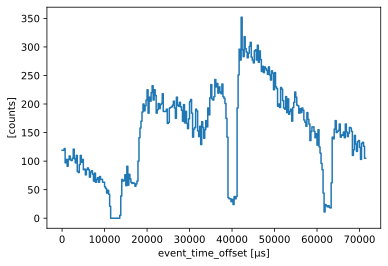

In [27]:
raw_data = ess_beamline.get_monitor("detector")[0]

# Visualize
raw_data.hist(event_time_offset=300).squeeze().plot()

### Creating the lookup table for ODIN

We update the workflow with the new beamline parameters to compute the wavelength lookup table.

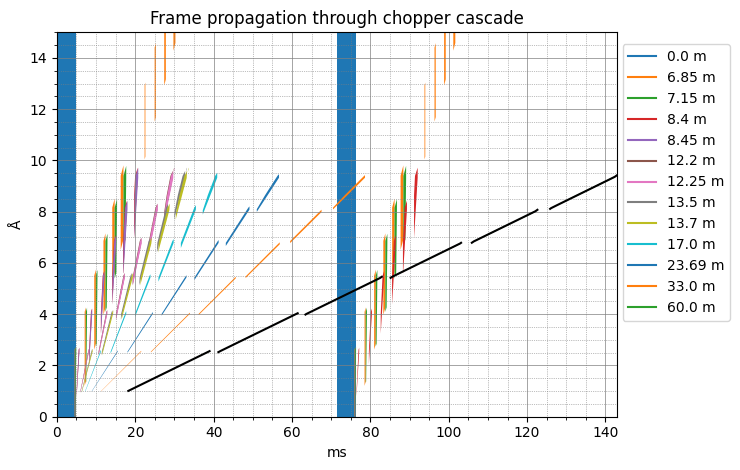

In [28]:
wf[DiskChoppers[SampleRun]] = odin_choppers
wf[Position[snx.NXsource, SampleRun]] = source_position
wf[DetectorLtotal[SampleRun]] = Ltotal

frames = wf.compute(ChopperFrameSequence[SampleRun])
at_detector = frames.propagate_to(Ltotal)
fig, ax = at_detector.draw()

table = wf.compute(LookupTable[SampleRun, snx.NXdetector])

# Overlay LUT prediction on the polygons figure
da = table.array["distance", 2]
ax.plot(
    da.coords['event_time_offset'].values / 1000,
    da.values,
    color="k",
    ls="-",
    marker=None,
)
ax.legend(loc=(1.01, 0.25))

The final relation between time-of-arrival and wavelength at the detector is represented by the black lines that accurately trace the green polygons
(zooming in on the figure may be required to even see the polygons at 60 m).

Also note that because of the pulse skipping, we consider two source pulses (blue rectangles) instead of one in the DREAM case.
Both pulses generate sets of polygons up to 8.4 m, but beyond that only the first pulses continues to travel down the beamline,
while the second pulse got blocked by the 7 Hz chopper.

In addition, we also draw the reader's attention to the fact that the table now spans two pulse periods (from 0-142 ms) instead of one;
a pulse stride of 2 was automatically detected from the chopper rotation frequencies.

The full wavelength lookup table is plotted below.

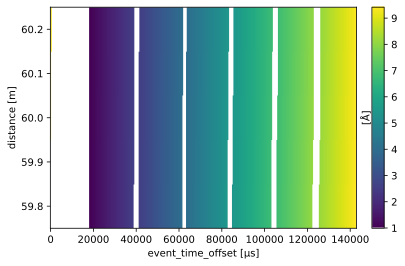

In [29]:
table.plot()

### Computing wavelengths for ODIN

Computing wavelengths is done in exactly the same way as for DREAM above.

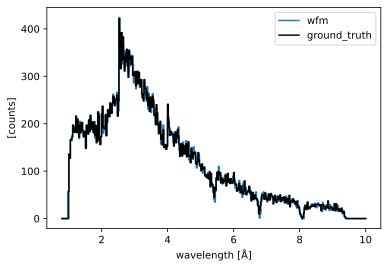

In [30]:
wf[RawDetector[SampleRun]] = raw_data
wf[NeXusDetectorName] = 'odin_detector'
wf[LookupTableRelativeErrorThreshold] = {'odin_detector': float("inf")}

wf.visualize(WavelengthDetector[SampleRun])

# Compute wavelength of neutron events
wavs = wf.compute(WavelengthDetector[SampleRun])
edges = sc.linspace("wavelength", 0.8, 10.0, 401, unit="angstrom")

histogrammed = wavs.hist(wavelength=edges).squeeze()

ground_truth = ess_beamline.model_result["detector"].data.flatten(to="event")
ground_truth = ground_truth[~ground_truth.masks["blocked_by_others"]]

pp.plot(
    {
        "wfm": histogrammed,
        "ground_truth": ground_truth.hist(wavelength=edges),
    },
    color={"ground_truth": "k"},
)